In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df_movies = pd.read_csv('../../../data/raw/lecture/tmdb_5000_movies.csv')
df_credits = pd.read_csv('../../../data/raw/lecture/tmdb_5000_credits.csv')

In [3]:
df = df_movies.merge(df_credits, 
                     left_on='id', right_on='movie_id',
                     suffixes=('_movies', '_credits'))
len(df)

4803

In [4]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989,57165.484281
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891,88694.614033
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,5.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000,9014.500000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000,14629.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000,58610.500000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000,459488.000000


In [5]:
df = df[(df['revenue'] != 0) & (df['budget'] != 0)]
len(df)

3229

In [6]:
df.describe()

,budget,id,popularity,revenue,runtime,vote_average,vote_count,movie_id
count,3.229000e+03,3229.000000,3229.000000,3.229000e+03,3229.000000,3229.000000,3229.000000,3229.000000
mean,4.065444e+07,44780.705791,29.033689,1.212430e+08,110.724373,6.309353,977.287395,44780.705791
std,4.439674e+07,74609.434723,36.165730,1.863029e+08,20.965694,0.873891,1414.309577,74609.434723
min,1.000000e+00,5.000000,0.019984,5.000000e+00,41.000000,0.000000,0.000000,5.000000
25%,1.050000e+07,4958.000000,10.446722,1.700000e+07,96.000000,5.800000,178.000000,4958.000000
50%,2.500000e+07,11451.000000,20.410354,5.518472e+07,107.000000,6.300000,471.000000,11451.000000
75%,5.500000e+07,45272.000000,37.335721,1.462920e+08,121.000000,6.900000,1148.000000,45272.000000
max,3.800000e+08,417859.000000,875.581305,2.787965e+09,338.000000,8.500000,13752.000000,417859.000000


In [11]:
df = df[(df['vote_count'] != 0) & (df['vote_average'] != 0)]
len(df)

3227

In [12]:
df['profit'] = df['revenue'] - df['budget']
df['profit']

0       2550965087
1        661000000
2        635674609
3        834939099
4         24139100
           ...    
4773       3124130
4788       5988000
4792         79000
4796        417760
4798       1820920
Name: profit, Length: 3227, dtype: int64

In [19]:
lang_group_df = df.groupby('original_language').mean(numeric_only=True)[['budget', 'revenue', 'vote_count']]
lang_group_df

,budget,revenue,vote_count
original_language,,,
af,3.000000e+06,9.879971e+06,94.000000
cn,1.984339e+07,6.296073e+07,327.000000
da,1.510000e+07,5.232305e+07,703.250000
de,2.019886e+07,4.159554e+07,609.555556
en,4.168718e+07,1.246254e+08,998.921935
es,1.027506e+07,3.362737e+07,521.866667
fa,1.800000e+05,9.000000e+05,112.000000
fr,1.786534e+07,3.292465e+07,371.320000
he,2.000000e+06,1.112585e+07,291.000000


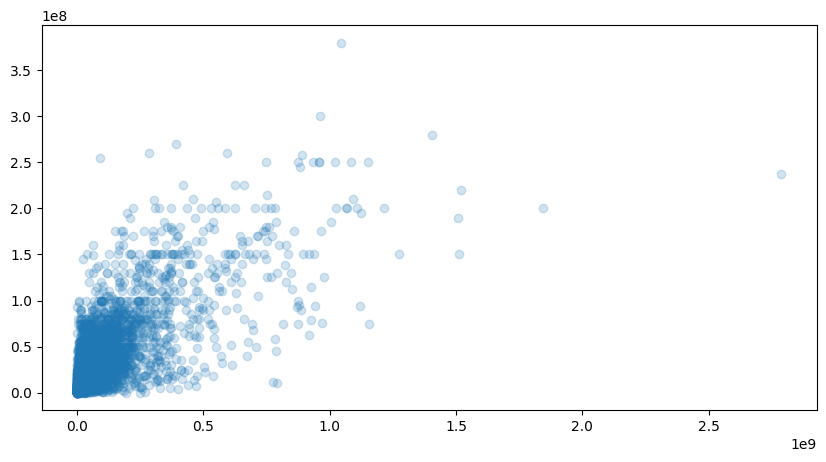

In [42]:
fig, axes = plt.subplots(figsize=(10, 5))
axes.scatter('revenue', 'budget', data=df, alpha=0.2)

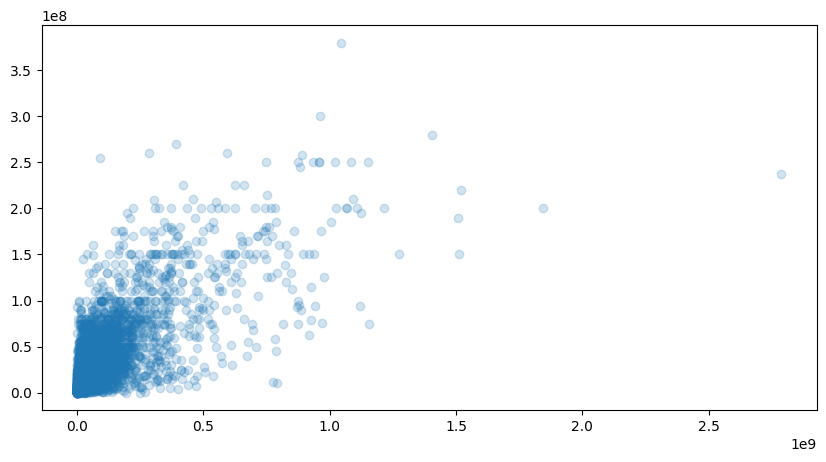

In [43]:
plt.figure(figsize=(10, 5))
plt.scatter('revenue', 'budget', data=df, alpha=0.2)

Text(0, 0.5, 'budget')

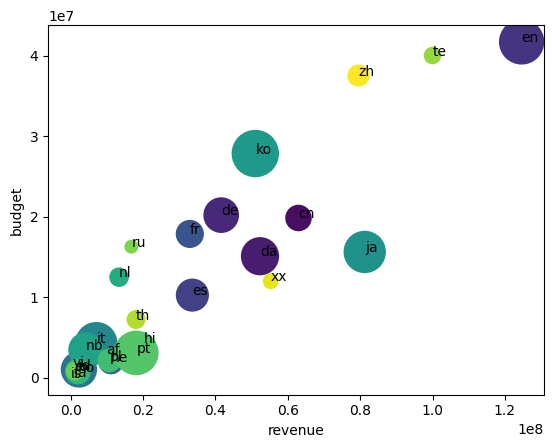

In [32]:
fig, axes = plt.subplots()

axes.scatter('revenue', 'budget', data=lang_group_df,
             s='vote_count',
             c=np.arange(len(lang_group_df)))
for idx, row in lang_group_df.iterrows():
    axes.annotate(idx, (row['revenue'], row['budget']))
axes.set_xlabel('revenue')
axes.set_ylabel('budget')

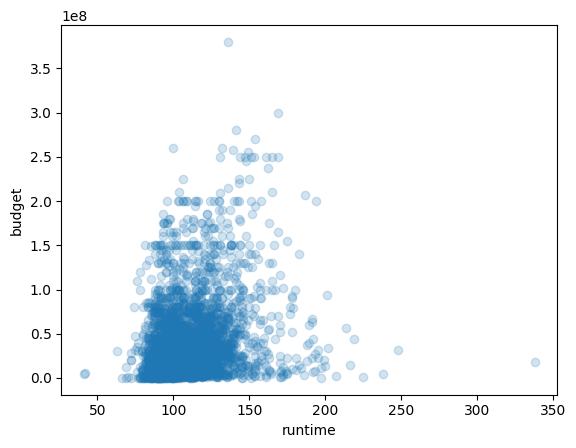

In [48]:
fig, axes = plt.subplots()
axes.scatter('runtime', 'budget', data=df, alpha=0.2)
axes.set_xlabel('runtime')
axes.set_ylabel('budget')
fig.savefig('runtime_budget_scatter.png')

In [52]:
np.linspace(1, 10, 10)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

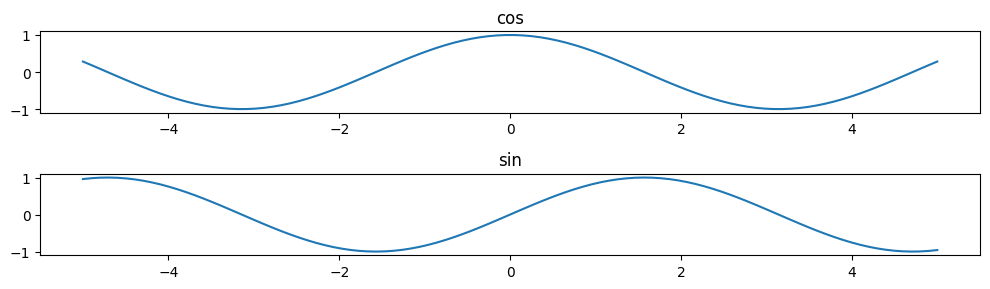

In [59]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3))
x = np.linspace(-5, 5, 100)
axes[0].plot(x, np.cos(x))
axes[1].plot(x, np.sin(x))
axes[0].set_title('cos')
axes[1].set_title('sin')
fig.tight_layout()
fig.savefig('cos_sin.png')

In [60]:
from matplotlib.backends.backend_pdf import PdfPages

pdf = PdfPages('pdf_files.pdf')
pdf

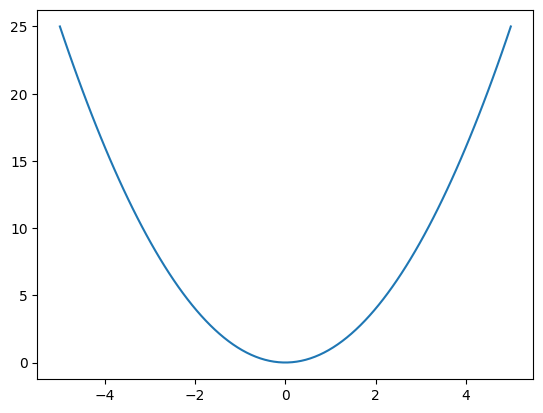

In [64]:
fig, axes = plt.subplots()
axes.plot(x, x**2)
pdf.savefig(fig)
pdf.close()

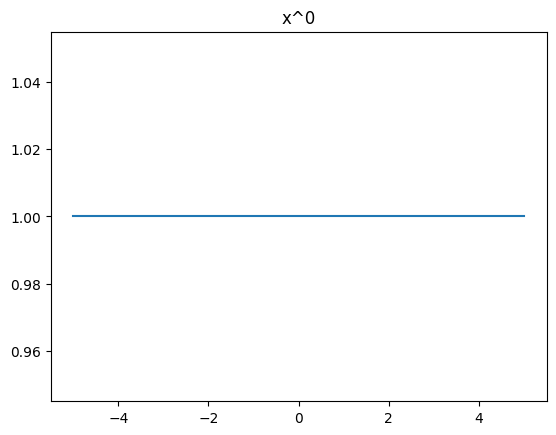

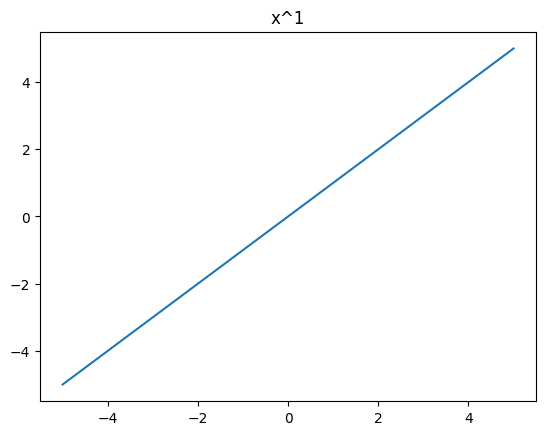

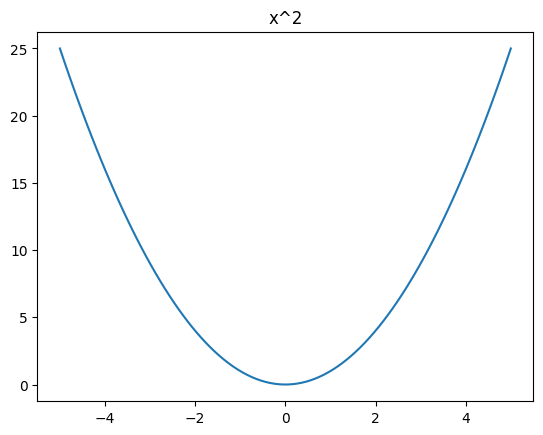

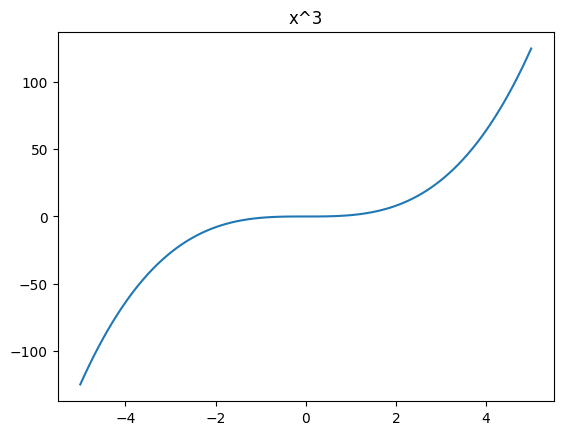

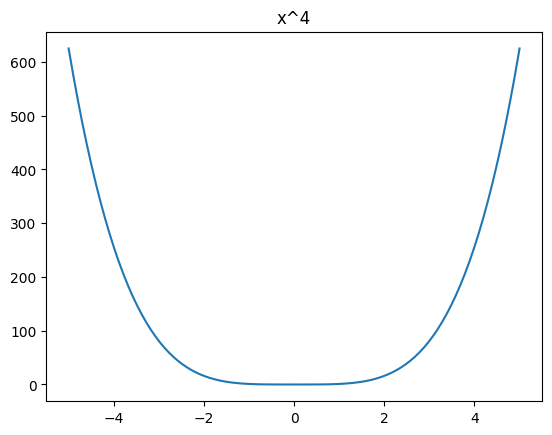

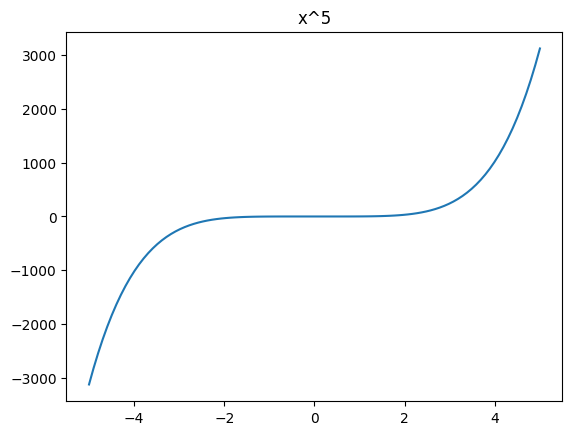

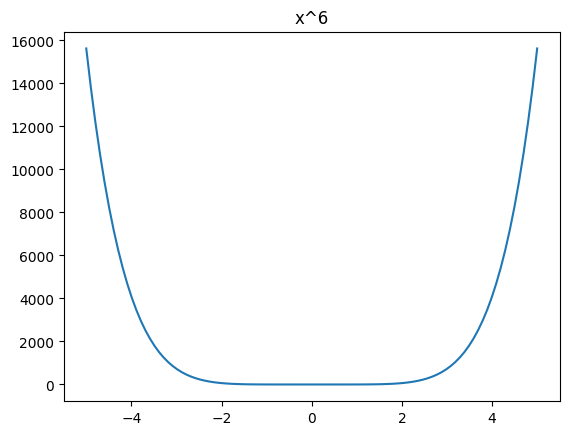

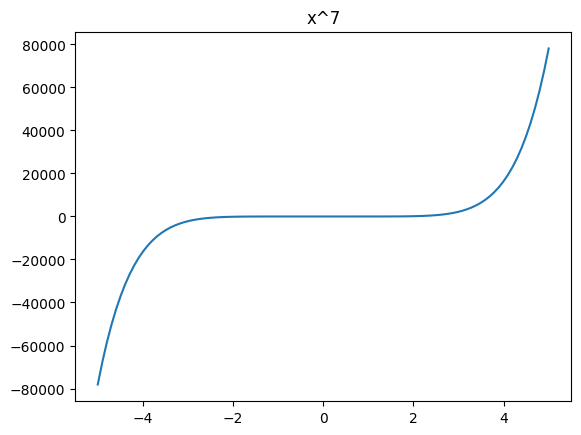

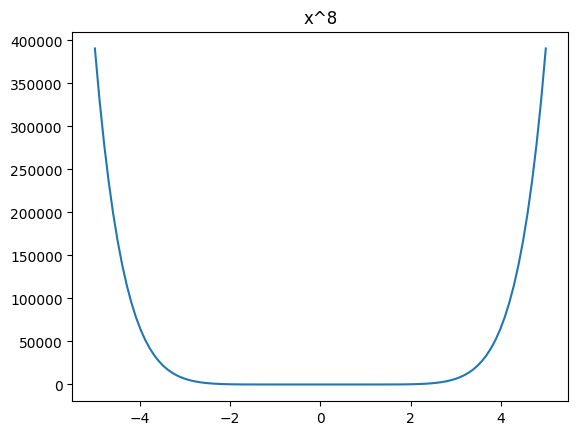

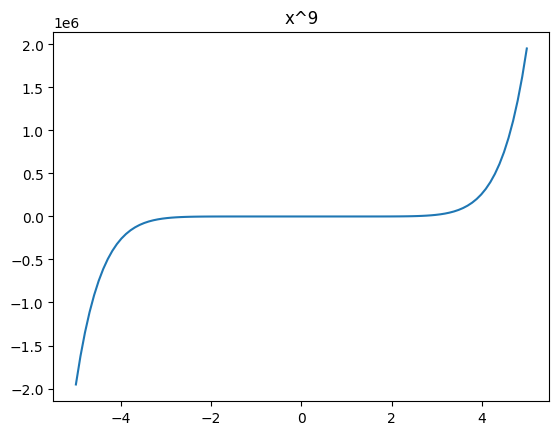

In [69]:
pdf = PdfPages('savemultifig_sample.pdf')
for i in range(10):
    fig, axes = plt.subplots()
    axes.plot(x, x**i)
    axes.set_title(f'x^{i}')
    pdf.savefig(fig)

pdf.close()